### ML Forecast benchmarking for GPU Power draw  

#### No exogeneous variables 

In [1]:
import pandas as pd

In [2]:
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from mlforecast import MLForecast
from mlforecast.target_transforms import Differences

In [3]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [4]:
import polars as pl
import numpy as np
from utilsforecast.losses import mae, rmse, mse, mape, smape

In [5]:
Y_df = pd.read_csv('gpu_slurm_metrics_10s_cleaned.csv') # load the data
Y_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259185 entries, 0 to 1259184
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   timestamp               1259185 non-null  object 
 1   gpu_index               1259185 non-null  int64  
 2   utilization_gpu_pct     1259185 non-null  float64
 3   utilization_memory_pct  1259185 non-null  float64
 4   temperature_gpu         1259185 non-null  float64
 5   temperature_memory      1259185 non-null  float64
 6   power_draw_W            1259185 non-null  float64
 7   id_job                  1259185 non-null  int64  
 8   time_start              1259185 non-null  float64
 9   time_end                1259185 non-null  float64
dtypes: float64(7), int64(2), object(1)
memory usage: 96.1+ MB


In [6]:
Y_df['unique_id'] = Y_df['id_job'].astype(str) + '_gpu' + Y_df['gpu_index'].astype(str)

In [7]:
Y_df['timestamp'] = pd.to_datetime(Y_df['timestamp'])
Y_df = Y_df.sort_values(by=['unique_id', 'timestamp'])

In [8]:
Y_df['y'] = Y_df['power_draw_W']

In [9]:
Y_df['ds'] = Y_df.groupby('unique_id').cumcount()

In [10]:
# This is the standard format for Nixtla.
prepared_df = Y_df[['unique_id', 'ds', 'y']]

print("Data prepared successfully. Head of the DataFrame:")
print(prepared_df.head())
print(f"\nNumber of unique time series (job-gpu combinations): {prepared_df['unique_id'].nunique()}")

Data prepared successfully. Head of the DataFrame:
                  unique_id  ds          y
264388  10217518336509_gpu0   0  54.939016
471025  10217518336509_gpu0   1  46.433710
264389  10217518336509_gpu0   2  53.556915
471026  10217518336509_gpu0   3  46.569681
264390  10217518336509_gpu0   4  52.611935

Number of unique time series (job-gpu combinations): 414


In [11]:
prepared_df.count()

unique_id    1259185
ds           1259185
y            1259185
dtype: int64

In [12]:
# pick a reference start time
start_time = pd.Timestamp("2023-01-01 00:00:00")

# convert ds (integer steps) into datetime
prepared_df['ds'] = pd.to_timedelta(prepared_df['ds'] * 10, unit='s') + start_time

/tmp/ipykernel_13924/2362352151.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prepared_df['ds'] = pd.to_timedelta(prepared_df['ds'] * 10, unit='s') + start_time


In [13]:
if isinstance(prepared_df, list):
    prepared_df = pd.DataFrame(prepared_df)

# Ensure required columns exist
print(prepared_df.dtypes)
print(prepared_df.tail())

unique_id            object
ds           datetime64[ns]
y                   float64
dtype: object
                 unique_id                  ds          y
463470  9976590120891_gpu1 2023-01-02 16:20:50  39.754217
463471  9976590120891_gpu1 2023-01-02 16:21:00  39.550602
463472  9976590120891_gpu1 2023-01-02 16:21:10  39.772892
463473  9976590120891_gpu1 2023-01-02 16:21:20  39.958072
463474  9976590120891_gpu1 2023-01-02 16:21:30  30.038966


In [14]:
prepared_df.dtypes

unique_id            object
ds           datetime64[ns]
y                   float64
dtype: object

In [15]:
# Define models
models = [
    XGBRegressor(
        objective='reg:squarederror',
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=0
    ),
    LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=0
    )
]


#### Cross validation of MLForecast models with different lags 

In [16]:

# Setup MLForecast
mlf = MLForecast(
    models=models,
    freq="10s",  # step index (10s)
    # target_transforms=[None, Differences([1])],   # difference transform for stationarity
    lags=list(range(1, 31)) + [60, 120, 180, 300, 600],  # short + medium + long lags
    num_threads=-1,  # Use all available cores

)

# Run cross-validation
# h=30 → horizon = 5 minutes (10s x 30)
# n_windows → number of rolling origin evaluations (try 3–5)
cv_df = mlf.cross_validation(
    df=prepared_df,   # your dataset with [unique_id, ds, y, exogenous...]
    h=30,
    n_windows=3,
)


/project/home/p200631/conda_base_path/miniconda3/envs/spark-env/lib/python3.11/site-packages/mlforecast/core.py:185: UserWarning: Setting num_threads to 1.
  warnings.warn("Setting num_threads to 1.")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022499 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8925
[LightGBM] [Info] Number of data points in the train set: 973525, number of used features: 35
[LightGBM] [Info] Start training from score 169.858814
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022083 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8925
[LightGBM] [Info] Number of data points in the train set: 985945, number of used features: 35
[LightGBM] [Info] Start training from score 170.143166
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009665 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8925
[LightGBM] [Info] Number of data points in the tra

In [17]:
cv_df.head()

,unique_id,ds,cutoff,y,XGBRegressor,LGBMRegressor
0,10217518336509_gpu0,2023-01-01 13:51:20,2023-01-01 13:51:10,169.805106,169.775940,168.267252
1,10217518336509_gpu0,2023-01-01 13:51:30,2023-01-01 13:51:10,180.077872,181.612335,181.050633
2,10217518336509_gpu0,2023-01-01 13:51:40,2023-01-01 13:51:10,171.071720,170.166397,169.879431
3,10217518336509_gpu0,2023-01-01 13:51:50,2023-01-01 13:51:10,183.791505,181.252365,180.181677
4,10217518336509_gpu0,2023-01-01 13:52:00,2023-01-01 13:51:10,166.119677,170.046677,169.832567


In [18]:
def evaluate_forecast(df, y_col="y", id_col="unique_id", ds_col="ds"):
    # Detect all forecast model columns (exclude id, ds, y)
    model_cols = [c for c in df.columns if c not in [id_col, ds_col, y_col, "Unnamed: 0", "cutoff"]]
    
    # Convert pandas → polars
    pl_df = pl.from_pandas(df[[id_col, y_col] + model_cols])
    
    # -----------------
    # Per-series metrics
    # -----------------
    results = {
        "MAE": mae(pl_df, models=model_cols, id_col=id_col, target_col=y_col),
        "RMSE": rmse(pl_df, models=model_cols, id_col=id_col, target_col=y_col),
        "MSE": mse(pl_df, models=model_cols, id_col=id_col, target_col=y_col),
        "MAPE": mape(pl_df, models=model_cols, id_col=id_col, target_col=y_col),
        "sMAPE": smape(pl_df, models=model_cols, id_col=id_col, target_col=y_col),
    }
    
    metrics_df = None
    for name, metric in results.items():
        metric = metric.rename({c: f"{c}_{name}" for c in metric.columns if c != id_col})
        metrics_df = metric if metrics_df is None else metrics_df.join(metric, on=id_col, how="inner")
    per_series_metrics = metrics_df.to_pandas()
    
    # -----------------
    # Global metrics
    # -----------------
    global_results = []
    y_true = df[y_col].values
    
    for model in model_cols:
        y_pred = df[model].values
        global_results.append({
            "Model": model,
            "MAE": np.mean(np.abs(y_true - y_pred)),
            "RMSE": np.sqrt(np.mean((y_true - y_pred) ** 2)),
            "MSE": np.mean((y_true - y_pred) ** 2),
            "MAPE": np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
            "sMAPE": np.mean(200 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))),
            "wMAPE": np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100,
        })
    
    global_metrics = pd.DataFrame(global_results)
    
    return per_series_metrics, global_metrics



In [19]:
### Results for MLForecast with lags only 
per_series_metrics, global_metrics = evaluate_forecast(cv_df)

print("Per-series metrics:\n", per_series_metrics.head())
print("\nGlobal metrics:\n", global_metrics)


Per-series metrics:
              unique_id  XGBRegressor_MAE  LGBMRegressor_MAE  \
0  10217518336509_gpu0          2.718708           2.558115   
1  10217518336509_gpu1          2.165938           2.199069   
2  10297115157410_gpu1          1.610550           1.620133   
3  10612452483078_gpu0          2.021764           2.007691   
4  10612452483078_gpu1          1.859552           1.922828   

   XGBRegressor_RMSE  LGBMRegressor_RMSE  XGBRegressor_MSE  LGBMRegressor_MSE  \
0           7.158682            7.183792         51.246722          51.606865   
1           6.500982            6.541947         42.262765          42.797065   
2           5.875264            5.890542         34.518728          34.698489   
3           7.049254            7.134210         49.691977          50.896946   
4           7.152042            7.096989         51.151702          50.367256   

   XGBRegressor_MAPE  LGBMRegressor_MAPE  XGBRegressor_sMAPE  \
0           0.017393            0.016539         

In [ ]:
2.966780  
12.131254  
147.167317  
2.596622  
1.919322 
1.546753 

#### Feature importance 

In [20]:
# Define models
models = [
    XGBRegressor(
        objective='reg:squarederror',
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=0
    ),
    LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=0
    )
]

# Setup MLForecast
mlf = MLForecast(
    models=models,
    freq="10s",  # step index (10s)
    # target_transforms=[None, Differences([1])],   # difference transform for stationarity
    lags=list(range(1, 31)) + [60, 120, 180, 300, 600],  # short + medium + long lags
    num_threads=-1,  # Use all available cores

)

/project/home/p200631/conda_base_path/miniconda3/envs/spark-env/lib/python3.11/site-packages/mlforecast/core.py:185: UserWarning: Setting num_threads to 1.
  warnings.warn("Setting num_threads to 1.")


In [21]:
mlf.fit(prepared_df)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020263 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8925
[LightGBM] [Info] Number of data points in the train set: 1010785, number of used features: 35
[LightGBM] [Info] Start training from score 170.667877


MLForecast(models=[XGBRegressor, LGBMRegressor], freq=10s, lag_features=['lag1', 'lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7', 'lag8', 'lag9', 'lag10', 'lag11', 'lag12', 'lag13', 'lag14', 'lag15', 'lag16', 'lag17', 'lag18', 'lag19', 'lag20', 'lag21', 'lag22', 'lag23', 'lag24', 'lag25', 'lag26', 'lag27', 'lag28', 'lag29', 'lag30', 'lag60', 'lag120', 'lag180', 'lag300', 'lag600'], date_features=[], num_threads=1)

In [22]:
mlf

MLForecast(models=[XGBRegressor, LGBMRegressor], freq=10s, lag_features=['lag1', 'lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7', 'lag8', 'lag9', 'lag10', 'lag11', 'lag12', 'lag13', 'lag14', 'lag15', 'lag16', 'lag17', 'lag18', 'lag19', 'lag20', 'lag21', 'lag22', 'lag23', 'lag24', 'lag25', 'lag26', 'lag27', 'lag28', 'lag29', 'lag30', 'lag60', 'lag120', 'lag180', 'lag300', 'lag600'], date_features=[], num_threads=1)

In [24]:
def plot_top_lags(mlf, top_n=20):
    """
    Plot top lags/features for XGB and LGBM models in an MLForecast object.
    
    Parameters:
    -----------
    mlf : MLForecast
        Fitted MLForecast object.
    top_n : int
        Number of top features to display per model.
    """
    fi_all = []

    for model_obj in mlf.models:
        trained = mlf.models_[model_obj]
        
        # Check if multiple series
        if isinstance(trained, dict):  # multiple unique_id series
            for series_id, tm in trained.items():
                if hasattr(tm, 'get_booster'):  # XGBRegressor
                    feature_names = tm.get_booster().feature_names
                else:  # LGBMRegressor
                    feature_names = tm.feature_name_
                
                importance = tm.feature_importances_
                
                fi_all.append(pd.DataFrame({
                    'model': model_obj,
                    'series_id': series_id,
                    'feature': feature_names,
                    'importance': importance
                }))
        else:  # single series
            tm = trained
            if hasattr(tm, 'get_booster'):  # XGBRegressor
                feature_names = tm.get_booster().feature_names
            else:  # LGBMRegressor
                feature_names = tm.feature_name_
            
            importance = tm.feature_importances_
            
            fi_all.append(pd.DataFrame({
                'model': model_obj,
                'series_id': None,
                'feature': feature_names,
                'importance': importance
            }))
    
    # Combine all models/series
    fi_df = pd.concat(fi_all, ignore_index=True)
    
    # Aggregate importance across series if multiple
    fi_mean = fi_df.groupby(['model','feature'])['importance'].mean().reset_index()
    
    # Plot top features per model
    for model_name in fi_mean['model'].unique():
        df_model = fi_mean[fi_mean['model'] == model_name].sort_values('importance', ascending=False).head(top_n)
        
        plt.figure(figsize=(10,6))
        plt.barh(df_model['feature'][::-1], df_model['importance'][::-1])
        plt.title(f'Top {top_n} Lags / Features - {model_name}')
        plt.xlabel('Importance')
        plt.show()


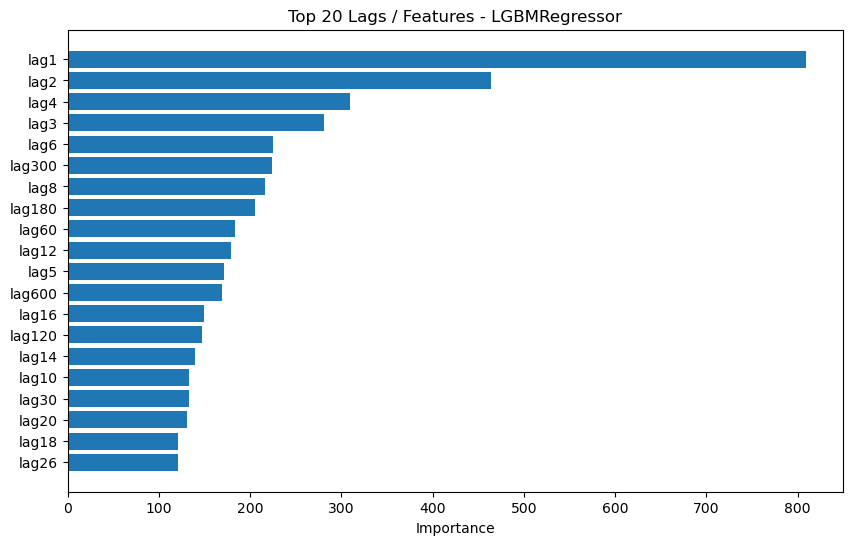

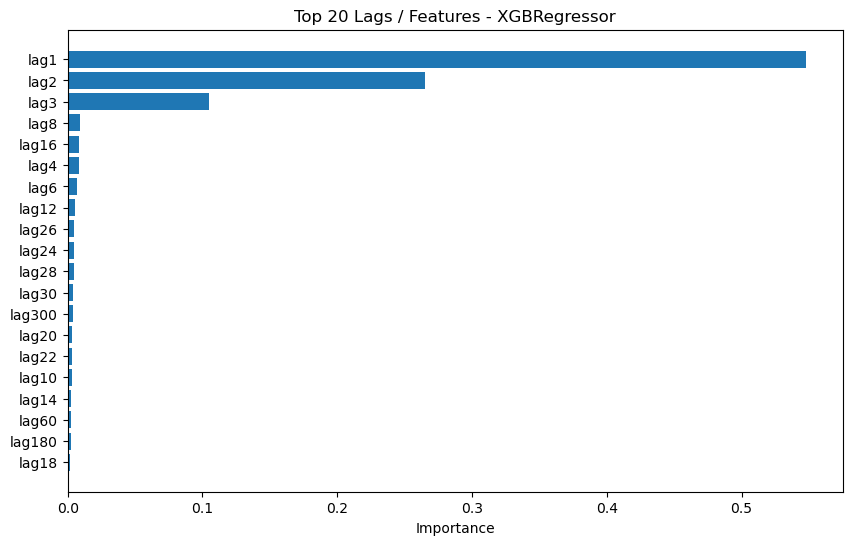

In [25]:
plot_top_lags(mlf, top_n=20)

In [26]:
#Adding rolling mean and expanding mean to lags 

In [27]:
from mlforecast.lag_transforms import RollingMean, ExpandingStd

In [28]:
# Setup MLForecast
mlf = MLForecast(
    models=models,
    freq="10s",  # step index (10s)
    # target_transforms=[None, Differences([1])],   # difference transform for stationarity
    lags=list(range(1, 31)) + [60, 120, 180, 300, 600],  # short + medium + long lags
    lag_transforms={
        1: [ExpandingStd()],
        2: [RollingMean(window_size=3, min_samples=1), RollingMean(window_size=6)]
    },
)

In [29]:
# Run cross-validation
# h=30 → horizon = 5 minutes (10s x 30)
# n_windows → number of rolling origin evaluations (try 3–5)
cv_df = mlf.cross_validation(
    df=prepared_df,   # your dataset with [unique_id, ds, y, exogenous...]
    h=30,
    n_windows=3,
)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.029375 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9690
[LightGBM] [Info] Number of data points in the train set: 973525, number of used features: 38
[LightGBM] [Info] Start training from score 169.858814
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023389 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9690
[LightGBM] [Info] Number of data points in the train set: 985945, number of used features: 38
[LightGBM] [Info] Start training from score 170.143166
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.025446 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9690
[LightGBM] [Info] Number of data points in the train set: 998365, number of used features: 38
[LightGBM] [Info] St

In [30]:
cv_df.head()

,unique_id,ds,cutoff,y,XGBRegressor,LGBMRegressor
0,10217518336509_gpu0,2023-01-01 13:51:20,2023-01-01 13:51:10,169.805106,169.817169,169.831171
1,10217518336509_gpu0,2023-01-01 13:51:30,2023-01-01 13:51:10,180.077872,182.071869,182.315194
2,10217518336509_gpu0,2023-01-01 13:51:40,2023-01-01 13:51:10,171.071720,170.125366,170.105019
3,10217518336509_gpu0,2023-01-01 13:51:50,2023-01-01 13:51:10,183.791505,182.473190,181.592681
4,10217518336509_gpu0,2023-01-01 13:52:00,2023-01-01 13:51:10,166.119677,169.898895,169.940221


In [31]:
### Results for MLForecast with lag transforms 
per_series_metrics, global_metrics = evaluate_forecast(cv_df)

print("Per-series metrics:\n", per_series_metrics.head())
print("\nGlobal metrics:\n", global_metrics)

Per-series metrics:
              unique_id  XGBRegressor_MAE  LGBMRegressor_MAE  \
0  10217518336509_gpu0          2.575480           2.541589   
1  10217518336509_gpu1          2.109700           2.256499   
2  10297115157410_gpu1          1.627703           1.626840   
3  10612452483078_gpu0          1.994598           2.026208   
4  10612452483078_gpu1          1.925598           1.944277   

   XGBRegressor_RMSE  LGBMRegressor_RMSE  XGBRegressor_MSE  LGBMRegressor_MSE  \
0           7.191904            7.203252         51.723485          51.886845   
1           6.496273            6.624591         42.201559          43.885199   
2           5.891939            5.892156         34.714947          34.717501   
3           7.074008            7.105442         50.041586          50.487303   
4           7.153580            7.180997         51.173703          51.566723   

   XGBRegressor_MAPE  LGBMRegressor_MAPE  XGBRegressor_sMAPE  \
0           0.016638            0.016475         

In [ ]:
2.939529  
12.018321  
144.440036  
2.549649  
1.903623   
1.532545

In [32]:
mlf.fit(prepared_df)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.034558 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9690
[LightGBM] [Info] Number of data points in the train set: 1010785, number of used features: 38
[LightGBM] [Info] Start training from score 170.667877


MLForecast(models=[XGBRegressor, LGBMRegressor], freq=10s, lag_features=['lag1', 'lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7', 'lag8', 'lag9', 'lag10', 'lag11', 'lag12', 'lag13', 'lag14', 'lag15', 'lag16', 'lag17', 'lag18', 'lag19', 'lag20', 'lag21', 'lag22', 'lag23', 'lag24', 'lag25', 'lag26', 'lag27', 'lag28', 'lag29', 'lag30', 'lag60', 'lag120', 'lag180', 'lag300', 'lag600', 'expanding_std_lag1', 'rolling_mean_lag2_window_size3_min_samples1', 'rolling_mean_lag2_window_size6'], date_features=[], num_threads=1)

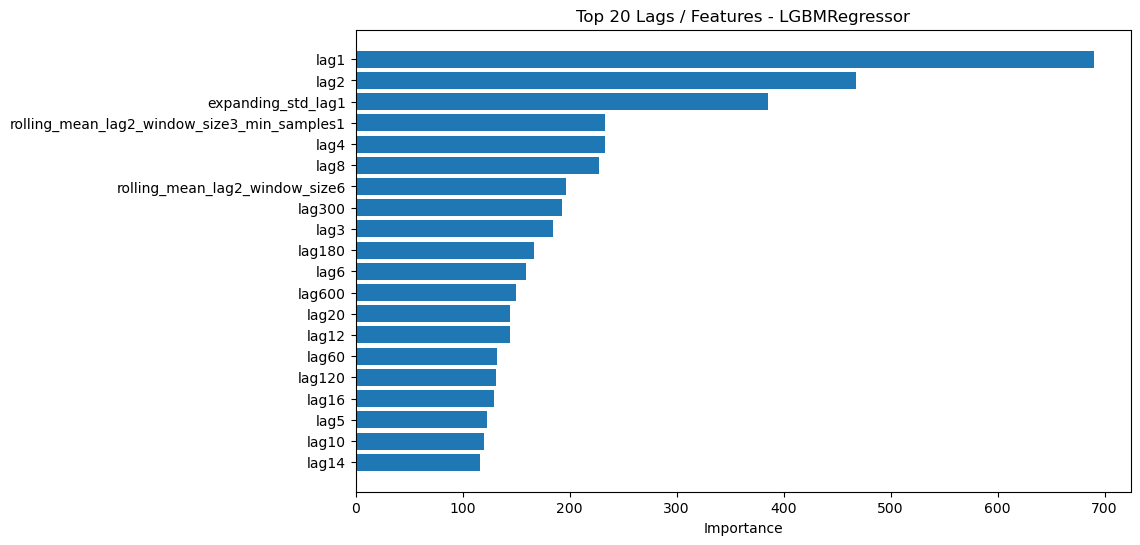

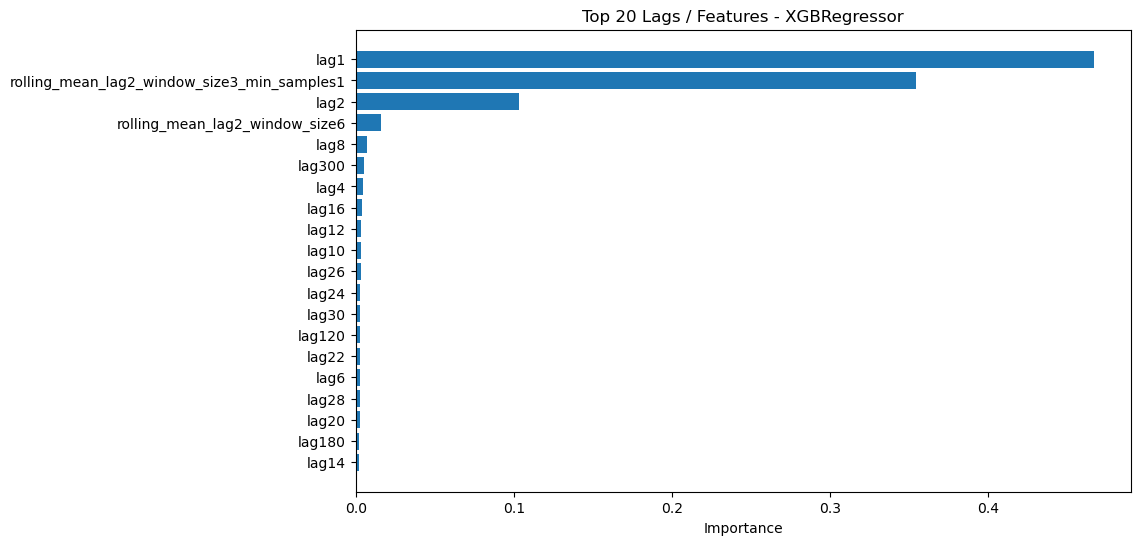

In [33]:
plot_top_lags(mlf, top_n=20)

### Predictions compared to real values plotting 

In [34]:
cv_df.head()

,unique_id,ds,cutoff,y,XGBRegressor,LGBMRegressor
0,10217518336509_gpu0,2023-01-01 13:51:20,2023-01-01 13:51:10,169.805106,169.817169,169.831171
1,10217518336509_gpu0,2023-01-01 13:51:30,2023-01-01 13:51:10,180.077872,182.071869,182.315194
2,10217518336509_gpu0,2023-01-01 13:51:40,2023-01-01 13:51:10,171.071720,170.125366,170.105019
3,10217518336509_gpu0,2023-01-01 13:51:50,2023-01-01 13:51:10,183.791505,182.473190,181.592681
4,10217518336509_gpu0,2023-01-01 13:52:00,2023-01-01 13:51:10,166.119677,169.898895,169.940221


In [35]:
from statsforecast import StatsForecast

In [42]:
fcst_no_e = cv_df[["unique_id", "ds", "XGBRegressor", "LGBMRegressor"]]

In [43]:
test_df = cv_df[["unique_id", "ds", "y"]]

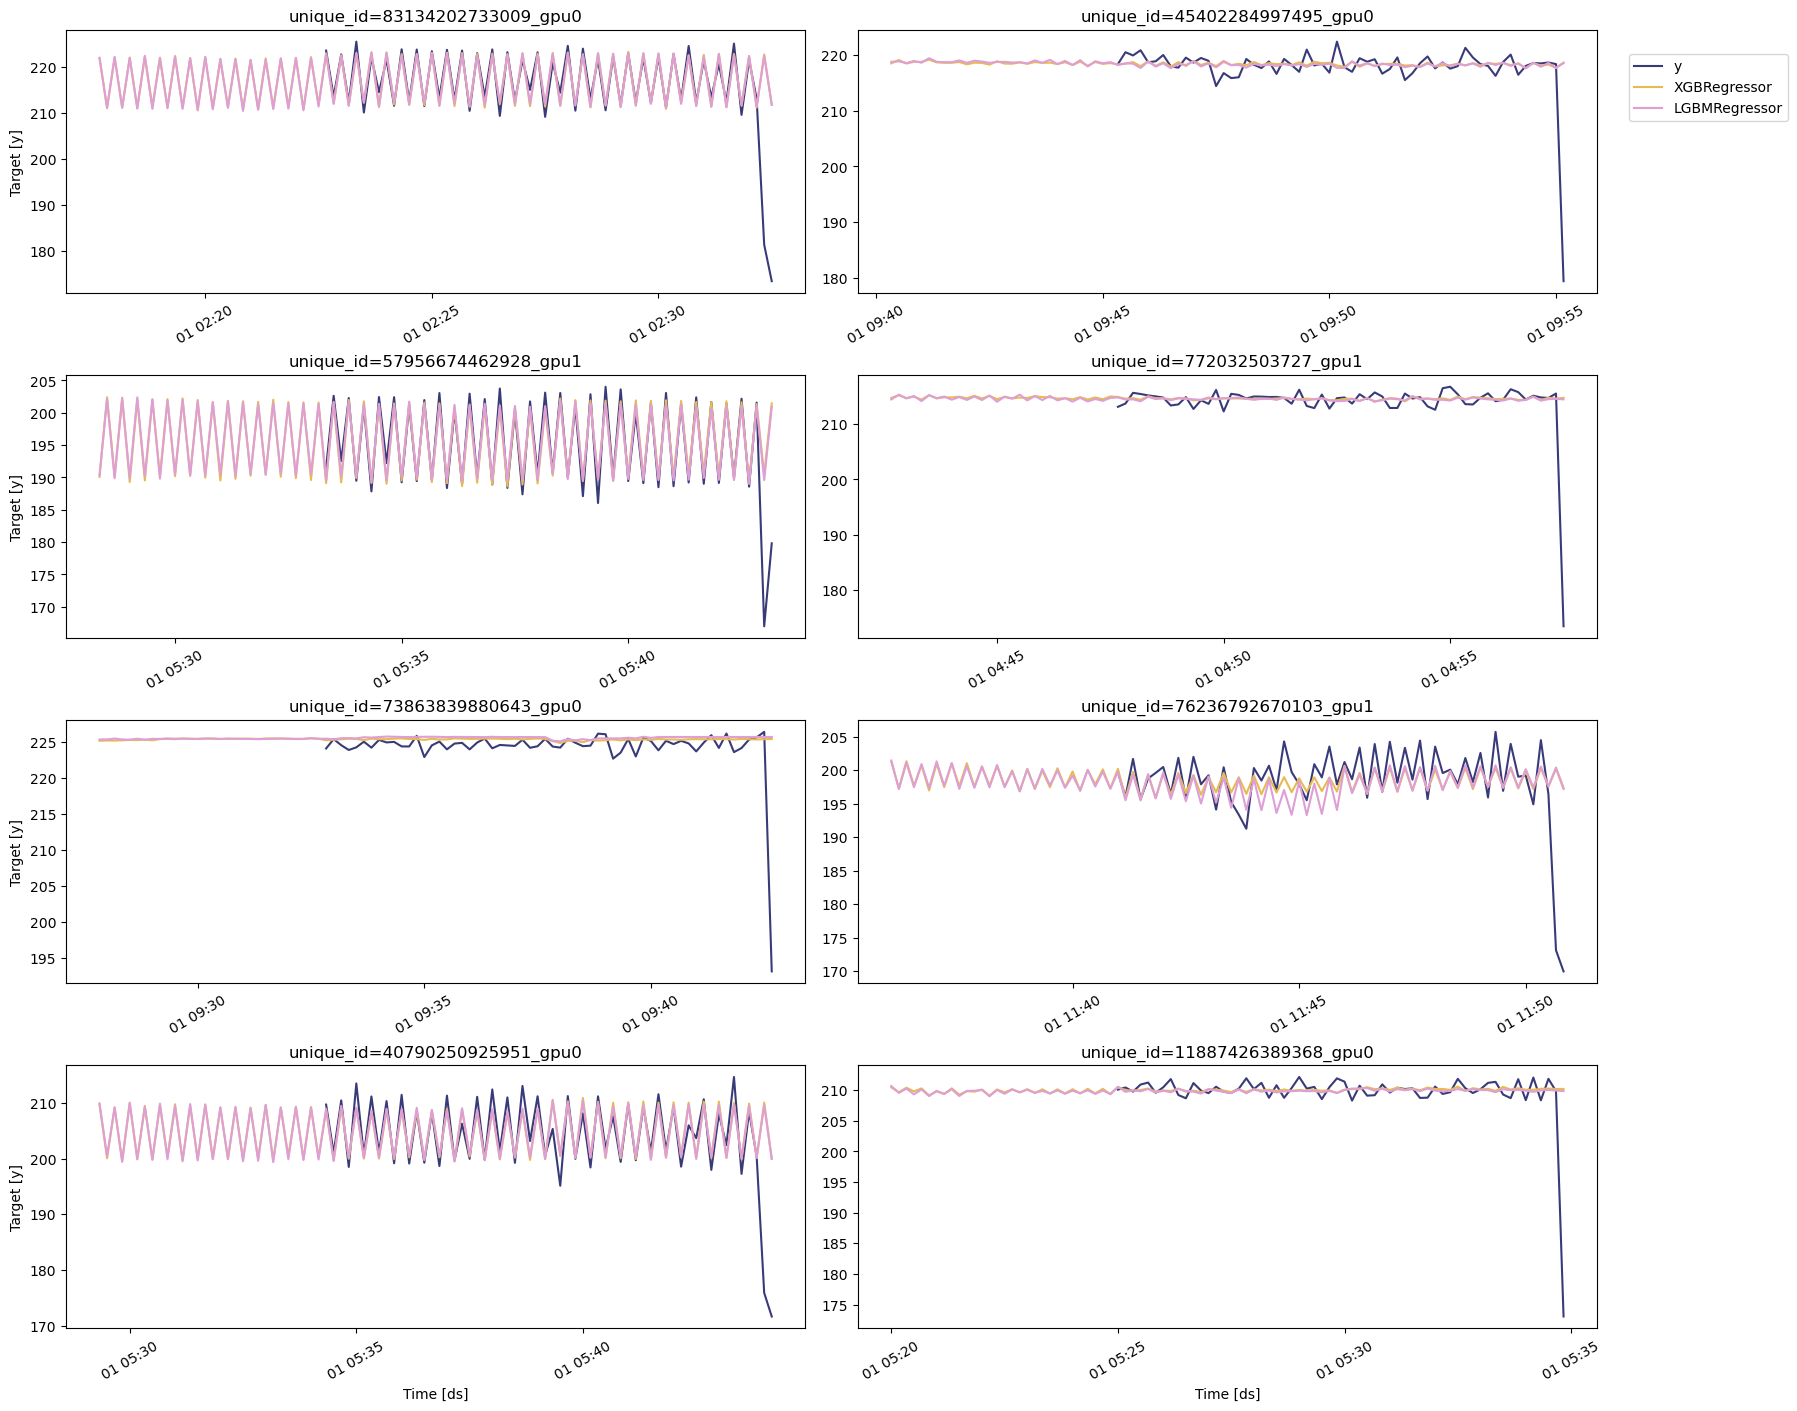

In [45]:
StatsForecast.plot(test_df, fcst_no_e, max_insample_length=60)

#### With exogeneous values

In [46]:
Y_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1259185 entries, 264388 to 463474
Data columns (total 13 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   timestamp               1259185 non-null  datetime64[ns]
 1   gpu_index               1259185 non-null  int64         
 2   utilization_gpu_pct     1259185 non-null  float64       
 3   utilization_memory_pct  1259185 non-null  float64       
 4   temperature_gpu         1259185 non-null  float64       
 5   temperature_memory      1259185 non-null  float64       
 6   power_draw_W            1259185 non-null  float64       
 7   id_job                  1259185 non-null  int64         
 8   time_start              1259185 non-null  float64       
 9   time_end                1259185 non-null  float64       
 10  unique_id               1259185 non-null  object        
 11  y                       1259185 non-null  float64       
 12  ds             

In [47]:
Y_df.drop(['power_draw_W', 'timestamp', 'gpu_index', 'id_job' , 'time_start', 'time_end'], axis =1, inplace=True)

In [48]:
# Setup MLForecast
mlf = MLForecast(
    models=models,
    freq=1,  # step index (10s)
    # target_transforms=[None, Differences([1])],   # difference transform for stationarity
    lags=list(range(1, 31)) + [60, 120, 180, 300, 600],  # short + medium + long lags
    lag_transforms={
        1: [ExpandingStd()],
        2: [RollingMean(window_size=3, min_samples=1), RollingMean(window_size=6)]
    },
)

In [49]:
# Run cross-validation
# h=30 → horizon = 5 minutes (10s x 30)
# n_windows → number of rolling origin evaluations (try 3–5)
cv_df = mlf.cross_validation(
    df=Y_df,   # your dataset with [unique_id, ds, y, exogenous...]
    h=30,
    n_windows=3,
    static_features=[],
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.037739 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10710
[LightGBM] [Info] Number of data points in the train set: 973525, number of used features: 42
[LightGBM] [Info] Start training from score 169.858814
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021635 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10710
[LightGBM] [Info] Number of data points in the train set: 985945, number of used features: 42
[LightGBM] [Info] Start training from score 170.143166
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.027312 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10710
[LightGBM] [Info] Number of data points in the train set: 998365, number of used features: 42
[LightGBM] [Info]

In [50]:
### Results for MLForecast with exogeneous variables and lag transforms 
per_series_metrics, global_metrics = evaluate_forecast(cv_df)

print("Per-series metrics:\n", per_series_metrics.head())
print("\nGlobal metrics:\n", global_metrics)

Per-series metrics:
              unique_id  XGBRegressor_MAE  LGBMRegressor_MAE  \
0  10217518336509_gpu0          1.622452           1.730272   
1  10217518336509_gpu1          1.266264           1.606563   
2  10297115157410_gpu1          1.256071           1.231446   
3  10612452483078_gpu0          1.156195           1.214915   
4  10612452483078_gpu1          1.136824           1.226409   

   XGBRegressor_RMSE  LGBMRegressor_RMSE  XGBRegressor_MSE  LGBMRegressor_MSE  \
0           2.300260            2.885972          5.291195           8.328832   
1           1.783946            2.962315          3.182464           8.775311   
2           2.086974            1.893456          4.355461           3.585174   
3           1.732549            2.100198          3.001727           4.410832   
4           1.975071            2.298063          3.900906           5.281093   

   XGBRegressor_MAPE  LGBMRegressor_MAPE  XGBRegressor_sMAPE  \
0           0.009561            0.010344         

In [ ]:
1.408621  
2.442300  
5.964829  
0.857855  
0.837430  
0.734395

In [51]:
mlf.fit(Y_df, static_features=[])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010156 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10710
[LightGBM] [Info] Number of data points in the train set: 1010785, number of used features: 42
[LightGBM] [Info] Start training from score 170.667877


MLForecast(models=[XGBRegressor, LGBMRegressor], freq=1, lag_features=['lag1', 'lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7', 'lag8', 'lag9', 'lag10', 'lag11', 'lag12', 'lag13', 'lag14', 'lag15', 'lag16', 'lag17', 'lag18', 'lag19', 'lag20', 'lag21', 'lag22', 'lag23', 'lag24', 'lag25', 'lag26', 'lag27', 'lag28', 'lag29', 'lag30', 'lag60', 'lag120', 'lag180', 'lag300', 'lag600', 'expanding_std_lag1', 'rolling_mean_lag2_window_size3_min_samples1', 'rolling_mean_lag2_window_size6'], date_features=[], num_threads=1)

In [52]:
mlf.ts.features_order_



['utilization_gpu_pct',
 'utilization_memory_pct',
 'temperature_gpu',
 'temperature_memory',
 'lag1',
 'lag2',
 'lag3',
 'lag4',
 'lag5',
 'lag6',
 'lag7',
 'lag8',
 'lag9',
 'lag10',
 'lag11',
 'lag12',
 'lag13',
 'lag14',
 'lag15',
 'lag16',
 'lag17',
 'lag18',
 'lag19',
 'lag20',
 'lag21',
 'lag22',
 'lag23',
 'lag24',
 'lag25',
 'lag26',
 'lag27',
 'lag28',
 'lag29',
 'lag30',
 'lag60',
 'lag120',
 'lag180',
 'lag300',
 'lag600',
 'expanding_std_lag1',
 'rolling_mean_lag2_window_size3_min_samples1',
 'rolling_mean_lag2_window_size6']

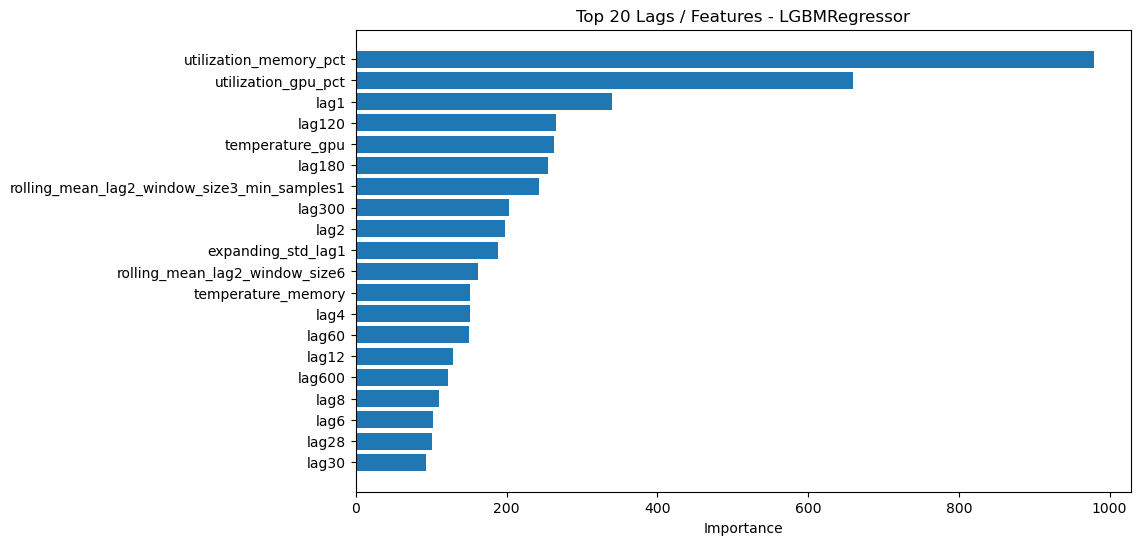

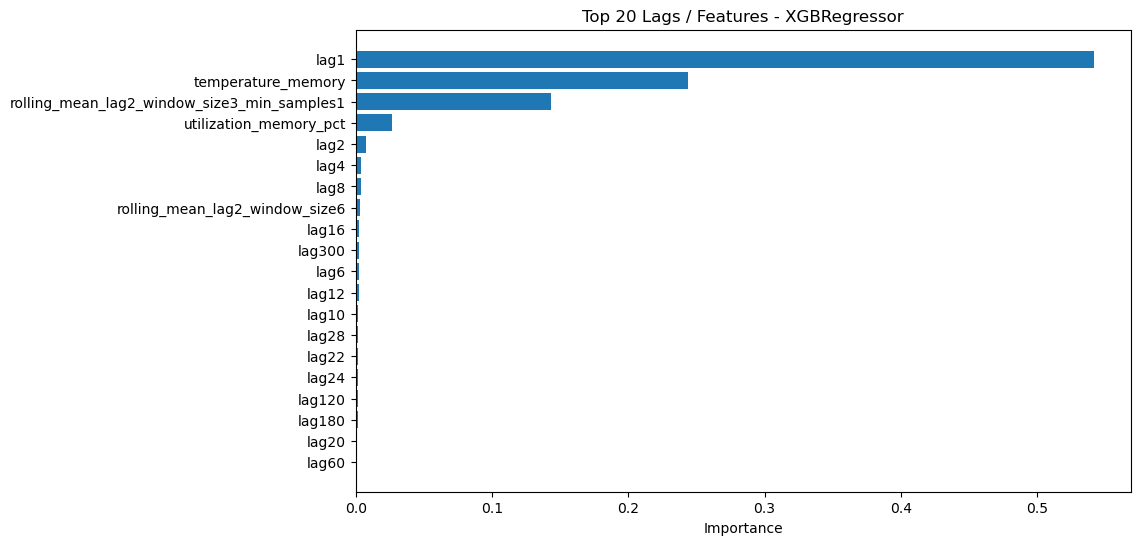

In [53]:
plot_top_lags(mlf, top_n=20)

In [54]:
Y_df.head()

,utilization_gpu_pct,utilization_memory_pct,temperature_gpu,temperature_memory,unique_id,y,ds
264388,6.360656,0.360656,65.180328,66.393443,10217518336509_gpu0,54.939016,0
471025,0.435484,0.000000,40.000000,38.080645,10217518336509_gpu0,46.433710,1
264389,0.031915,0.010638,63.638298,64.861702,10217518336509_gpu0,53.556915,2
471026,0.063830,0.021277,40.000000,38.042553,10217518336509_gpu0,46.569681,3
264390,1.150538,0.032258,62.311828,63.387097,10217518336509_gpu0,52.611935,4
